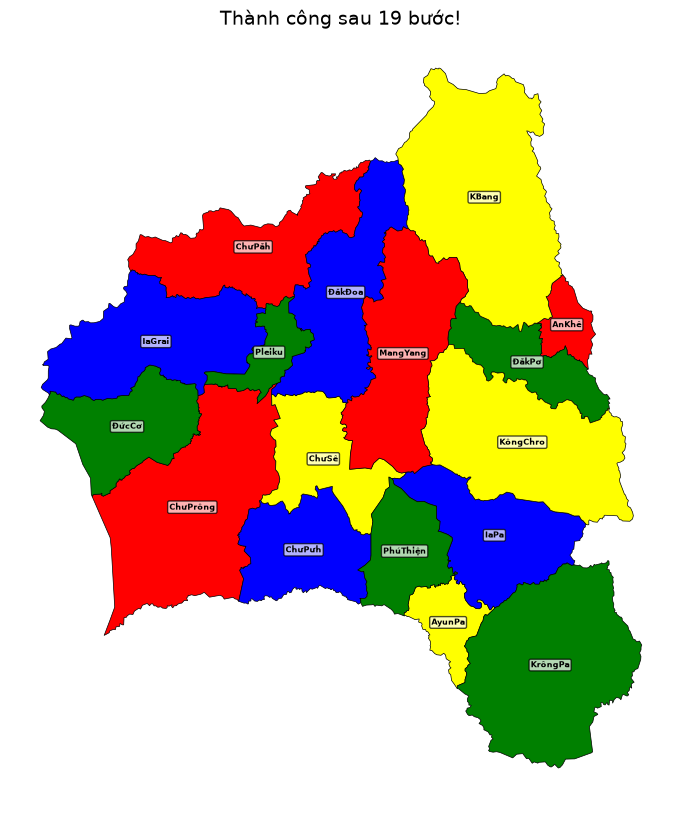

Bản đồ đã được tô hoàn chỉnh!


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import random

gdf = gpd.read_file("D:/Dai_Hoc/HK4_dot2/Tri Tue Nhan Tao/BAI_TAP_AI/ToBanDo/gia_lai_districts.json")
gia_lai_map = gdf[gdf['NAME_1'] == 'GiaLai'].copy()
if gia_lai_map.crs is None: gia_lai_map.set_crs(epsg=4326, inplace=True)
gia_lai_map = gia_lai_map.to_crs(epsg=3857)

adj_list = {}
for i, row in gia_lai_map.iterrows():
    neighbors = gia_lai_map[gia_lai_map.geometry.distance(row.geometry) < 0.001]['NAME_2'].tolist()
    adj_list[row['NAME_2']] = [n for n in neighbors if n != row['NAME_2']]

# HÀM VẼ GIAO DIỆN
def draw_step(step_assignment, title):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 10))
    current_colors = gia_lai_map['NAME_2'].map(step_assignment).fillna('lightgrey')
    gia_lai_map.plot(ax=ax, color=current_colors, edgecolor='black', linewidth=0.5)
    for idx, row in gia_lai_map.iterrows():
        centroid = row['geometry'].centroid
        plt.annotate(text=row['NAME_2'], xy=(centroid.x, centroid.y), 
                     ha='center', va='center', fontsize=6, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
    plt.title(title, fontsize=14)
    plt.axis('off'); plt.show(); time.sleep(0.05)

# THUẬT TOÁN MIN-CONFLICTS
def count_conflicts(district, color, current_assignment, adj_list):
    return sum(1 for neighbor in adj_list.get(district, []) if current_assignment.get(neighbor) == color)

def min_conflicts_solver(adj_list, colors, max_steps=1000):
    districts = list(adj_list.keys())
    # Khởi tạo ngẫu nhiên
    current = {d: random.choice(colors) for d in districts}
    
    for step in range(max_steps):
        # Tìm danh sách các huyện đang bị trùng màu với hàng xóm
        conflicted_vars = [d for d in districts if count_conflicts(d, current[d], current, adj_list) > 0]
        
        # Nếu không còn lỗi -> Thành công
        if not conflicted_vars:
            draw_step(current, f"Thành công sau {step} bước!")
            return current
        
        # Chọn ngẫu nhiên một huyện đang bị lỗi
        var = random.choice(conflicted_vars)
        
        # Chọn màu ít xung đột nhất cho huyện đó
        best_val = min(colors, key=lambda c: count_conflicts(var, c, current, adj_list))
        current[var] = best_val
        
        # Vẽ tiến trình
        draw_step(current, f"Đang sửa lỗi: Bước {step}")
        
    print(">>> THẤT BẠI: Không tìm được lời giải trong giới hạn bước.")
    return None

# CHẠY
colors = ['red', 'blue', 'yellow', 'green']
solution = min_conflicts_solver(adj_list, colors, max_steps=1000)

if solution:
    print("Bản đồ đã được tô hoàn chỉnh!")
else:
    print("Vui lòng thử chạy lại ô này để thuật toán khởi tạo ngẫu nhiên khác.")